# Analysis of Factors Influencing Airline Ticket Prices

This project investigates the factors associated with average airline fares and evaluates the ability of statistical and machine learning models to predict fares using market-, route-, carrier-, and competition-related characteristics.

The analysis uses the **Airline Market Fare Prediction Data** dataset developed by K. Gülnaz Bülbül from publicly available U.S. Bureau of Transportation Statistics (BTS) data.

**Research objective**

The analysis addresses two related questions:

1. Which market, route, carrier, and competition-related factors are associated with average airline fares?
2. How accurately can statistical and machine learning regression models predict average fares?

The workflow includes exploratory data analysis, feature assessment, regression modeling, ensemble methods, model comparison, feature importance, and robustness analysis.

> This project uses publicly available market-level data. It does not contain confidential or proprietary data from Azerbaijan Airlines or any other airline.

## 1. Setup

This section imports the libraries used for data manipulation and visualization, defines reproducibility settings, and establishes the project paths used throughout the notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42

TARGET = "Average_Fare"
MODELING_SAMPLE_SIZE = 200_000

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "MarketFarePredictionData.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: c:\Users\eldar\Desktop\portfolio\python\Analysis of Factors Influencing Airline Ticket Prices Using Statistical and Machine Learning Methods
Dataset path: c:\Users\eldar\Desktop\portfolio\python\Analysis of Factors Influencing Airline Ticket Prices Using Statistical and Machine Learning Methods\data\MarketFarePredictionData.csv


## 2. Data Loading and Validation

The dataset contains airline market observations constructed from the DB1B and T-100 datasets provided by the U.S. Bureau of Transportation Statistics. The processed dataset contains 26 variables covering route characteristics, passenger volumes, carrier activity, market concentration, competition, and average fares.

Before analysis, the dataset structure is validated to ensure that the expected variables are available.

In [5]:
EXPECTED_COLUMNS = [
    "MktCoupons",
    "OriginCityMarketID",
    "DestCityMarketID",
    "OriginAirportID",
    "DestAirportID",
    "Carrier",
    "NonStopMiles",
    "RoundTrip",
    "ODPairID",
    "Pax",
    "CarrierPax",
    "Average_Fare",
    "Market_share",
    "Market_HHI",
    "LCC_Comp",
    "Multi_Airport",
    "Circuity",
    "Slot",
    "Non_Stop",
    "MktMilesFlown",
    "OriginCityMarketID_freq",
    "DestCityMarketID_freq",
    "OriginAirportID_freq",
    "DestAirportID_freq",
    "Carrier_freq",
    "ODPairID_freq",
]

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download it using the instructions in data/README.md."
    )

df = pd.read_csv(DATA_PATH)

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(EXPECTED_COLUMNS))

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

if unexpected_columns:
    print(f"Unexpected columns detected: {unexpected_columns}")

Dataset loaded: 1,581,278 rows × 26 columns


In [7]:
dataset_overview = pd.Series(
    {
        "Rows": f"{len(df):,}",
        "Columns": df.shape[1],
        "Memory usage (MB)": f"{df.memory_usage(deep=True).sum() / 1024**2:,.1f}",
        "Target": TARGET,
    },
    name="Value",
)

display(dataset_overview.to_frame())
display(df.head())

,Value
Rows,"1,581,278"
Columns,26
Memory usage (MB),313.7
Target,Average_Fare


,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,CarrierPax,Average_Fare,Market_share,Market_HHI,LCC_Comp,Multi_Airport,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
0,2,178,152,170,255,6,"1,807.0000",1.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.3675,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0220,0.1168,0.0001
1,2,178,152,170,194,20,"1,798.0000",1.0000,4035,136.0000,40.0000,283.3200,0.2941,"5,847.7500",1,1,1.0517,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0084,0.3077,0.0001
2,2,178,152,170,260,6,"1,784.0000",0.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.0348,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0094,0.1168,0.0001
3,2,178,152,170,255,6,"1,807.0000",1.0000,4035,136.0000,96.0000,389.1000,0.7059,"5,847.7500",1,1,1.0299,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0220,0.1168,0.0001
4,2,178,152,170,194,20,"1,798.0000",1.0000,4035,136.0000,40.0000,283.3200,0.2941,"5,847.7500",1,1,1.0623,0,0.0000,"1,992.4498",0.0041,0.0398,0.0041,0.0084,0.3077,0.0001


## 3. Data Quality Assessment

Before exploring relationships in the data, basic quality checks are performed to identify missing values, exact duplicate rows, and structural issues that could affect subsequent analysis.

The dataset also contains several numerical identifiers. Although these columns are stored as integers, their values represent categories rather than continuous quantities. They are therefore separated from economically interpretable numerical features during exploratory correlation analysis.

In [8]:
IDENTIFIER_COLUMNS = [
    "OriginCityMarketID",
    "DestCityMarketID",
    "OriginAirportID",
    "DestAirportID",
    "Carrier",
    "ODPairID",
]

FREQUENCY_COLUMNS = [
    "OriginCityMarketID_freq",
    "DestCityMarketID_freq",
    "OriginAirportID_freq",
    "DestAirportID_freq",
    "Carrier_freq",
    "ODPairID_freq",
]

BINARY_FEATURES = [
    "RoundTrip",
    "LCC_Comp",
    "Multi_Airport",
    "Slot",
    "Non_Stop",
]

INTERPRETABLE_NUMERIC_FEATURES = [
    "MktCoupons",
    "NonStopMiles",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
    "MktMilesFlown",
    *BINARY_FEATURES,
]

In [9]:
quality_summary = pd.Series(
    {
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing values": int(df.isna().sum().sum()),
        "Duplicate rows": int(df.duplicated().sum()),
    },
    name="Value",
)

display(quality_summary.to_frame())

,Value
Rows,1581278
Columns,26
Missing values,0
Duplicate rows,1517905


### Descriptive Statistics

The summary below focuses on variables with direct analytical interpretations rather than encoded identifiers.

In [10]:
summary_columns = [
    TARGET,
    "NonStopMiles",
    "MktMilesFlown",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
]

display(
    df[summary_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Average_Fare,"1,581,278.0000",214.4831,73.3732,67.3900,166.9400,202.2700,246.6400,"1,265.9900"
NonStopMiles,"1,581,278.0000","1,183.1578",713.6535,100.0000,643.0000,"1,011.0000","1,590.0000","5,095.0000"
MktMilesFlown,"1,581,278.0000","1,213.7171",726.8271,102.0000,658.0258,"1,040.6415","1,639.1057","5,096.5207"
Pax,"1,581,278.0000","177,320.2494","238,028.8731",1.0000,"31,824.0000","86,543.0000","231,821.0000","1,495,396.0000"
CarrierPax,"1,581,278.0000","62,992.7908","88,025.5432",1.0000,"13,052.0000","31,068.0000","75,970.0000","706,835.0000"
Market_share,"1,581,278.0000",0.4872,0.2978,0.0500,0.2367,0.4273,0.7171,1.0000
Market_HHI,"1,581,278.0000","5,012.6265","2,494.3425","1,553.4200","3,057.0600","4,269.8200","6,339.9100","10,000.0000"
Circuity,"1,581,278.0000",1.0264,0.1092,1.0000,1.0000,1.0000,1.0000,2.9858


## 4. Target Variable Analysis

The prediction target is `Average_Fare`, representing the average fare associated with each market-carrier observation.

Its distribution is examined before modeling because substantial skewness and extreme values can affect regression performance and error metrics.

In [11]:
target_summary = pd.Series(
    {
        "Count": df[TARGET].count(),
        "Mean": df[TARGET].mean(),
        "Median": df[TARGET].median(),
        "Standard deviation": df[TARGET].std(),
        "Minimum": df[TARGET].min(),
        "Maximum": df[TARGET].max(),
        "Skewness": df[TARGET].skew(),
        "Excess kurtosis": df[TARGET].kurt(),
    },
    name="Value",
)

display(target_summary.to_frame())

,Value
Count,"1,581,278.0000"
Mean,214.4831
Median,202.2700
Standard deviation,73.3732
Minimum,67.3900
Maximum,"1,265.9900"
Skewness,2.4965
Excess kurtosis,15.5403


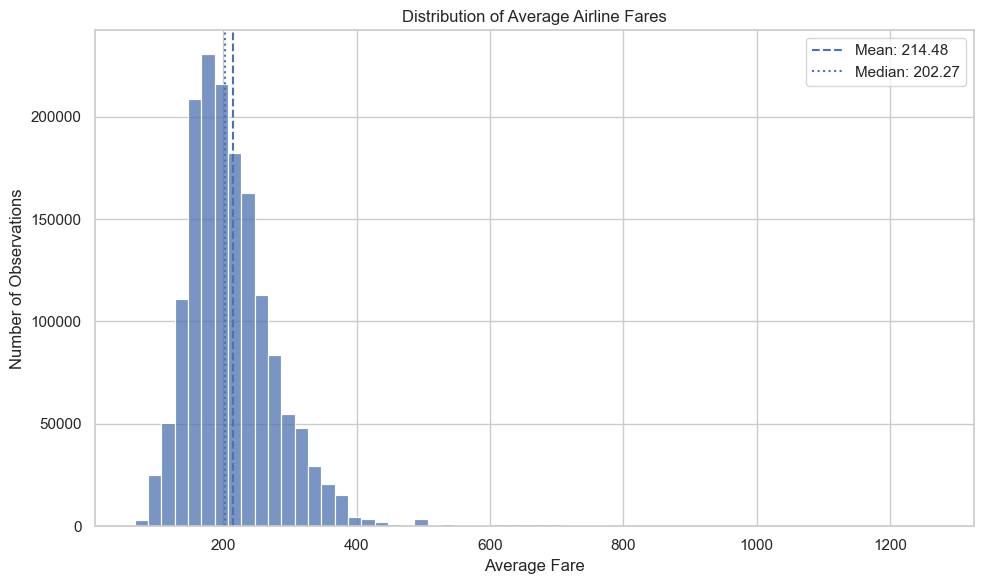

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x=TARGET,
    bins=60,
    ax=ax,
)

ax.axvline(
    df[TARGET].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {df[TARGET].mean():.2f}",
)

ax.axvline(
    df[TARGET].median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median: {df[TARGET].median():.2f}",
)

ax.set_title("Distribution of Average Airline Fares")
ax.set_xlabel("Average Fare")
ax.set_ylabel("Number of Observations")
ax.legend()

plt.tight_layout()
plt.show()

The target distribution is strongly right-skewed. The mean fare is approximately 214.48, compared with a median of approximately 202.27, while the maximum fare is substantially higher at 1,265.99.

The calculated skewness of approximately 2.50 and excess kurtosis of approximately 15.54 confirm a long right tail and a higher concentration of extreme values than would be expected under a normal distribution.

These characteristics motivate the use of both MAE and RMSE during model evaluation: MAE provides an interpretable measure of typical absolute prediction error, while RMSE places greater weight on larger errors.

## 5. Correlation Analysis

Pearson correlations are examined for variables with meaningful numerical interpretations.

Encoded identifiers such as carrier, airport, market, and origin-destination IDs are intentionally excluded. Although stored numerically, the differences between their integer values do not represent meaningful quantitative differences.

Frequency-encoded identifiers are also excluded from this descriptive correlation analysis because their interpretation differs from the underlying economic and route characteristics.

In [13]:
correlation_features = [
    TARGET,
    *INTERPRETABLE_NUMERIC_FEATURES,
]

correlation_matrix = df[correlation_features].corr()

target_correlations = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .rename("Correlation")
    .to_frame()
)

display(target_correlations)

,Correlation
NonStopMiles,0.7348
MktMilesFlown,0.7346
Market_HHI,0.2529
Market_share,0.2420
MktCoupons,0.2169
Non_Stop,-0.2140
LCC_Comp,-0.1726
Pax,-0.1618
CarrierPax,-0.1043
Circuity,0.0352


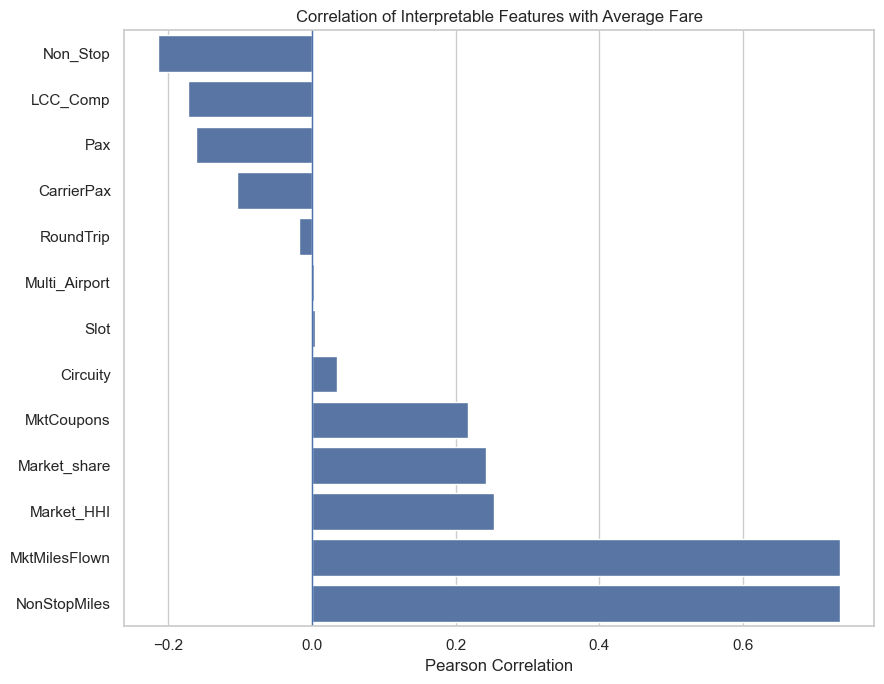

In [14]:
correlation_plot = (
    target_correlations
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("Correlation")
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=correlation_plot,
    x="Correlation",
    y="Feature",
    ax=ax,
)

ax.axvline(0, linewidth=1)
ax.set_title("Correlation of Interpretable Features with Average Fare")
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Distance-related variables show the strongest positive linear associations with average fares. `NonStopMiles` and `MktMilesFlown` both have correlations of approximately 0.73 with the target, indicating that longer markets generally exhibit higher average fares.

Market concentration (`Market_HHI`) and carrier market share (`Market_share`) show more moderate positive relationships of approximately 0.25 and 0.24, respectively.

These correlations describe association rather than causation. They also do not account for interactions among predictors or nonlinear relationships, which are examined later using machine learning models.

### Relationships Among Continuous Predictors

A reduced correlation matrix is used to examine relationships among the main continuous explanatory variables. This is particularly relevant for identifying strongly related predictors before estimating linear and regularized regression models.

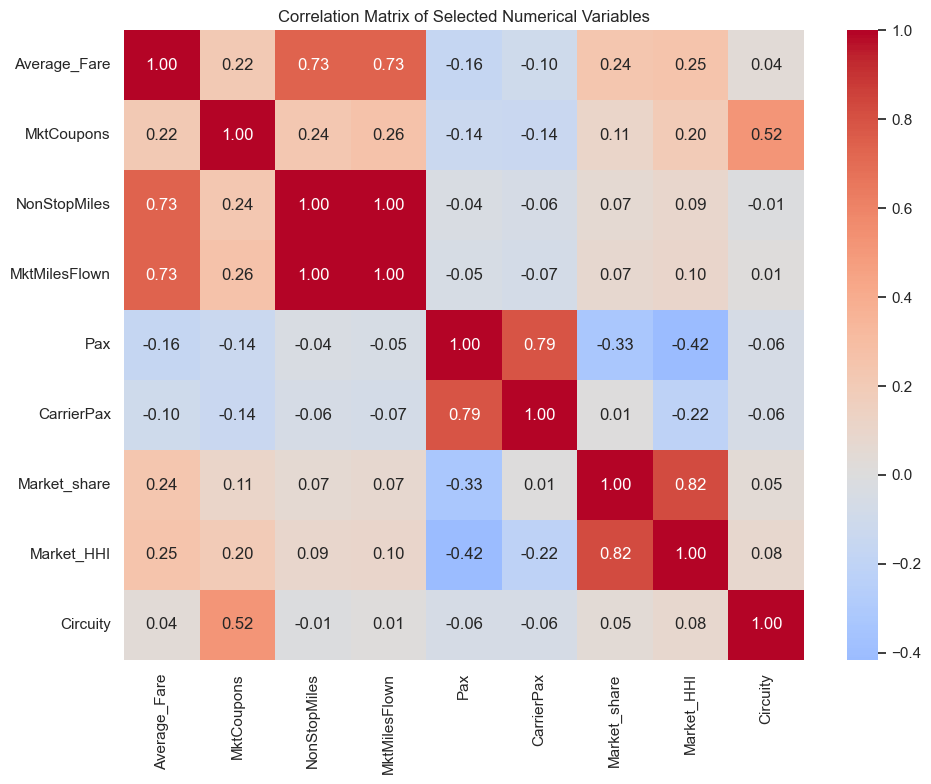

In [15]:
heatmap_features = [
    TARGET,
    "MktCoupons",
    "NonStopMiles",
    "MktMilesFlown",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "Circuity",
]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)

ax.set_title("Correlation Matrix of Selected Numerical Variables")

plt.tight_layout()
plt.show()

## 6. Relationships with Average Fare

Because the dataset contains more than 1.5 million observations, plotting every row would create substantial overplotting and unnecessary rendering cost. A reproducible random sample is therefore used for visualization only.

All descriptive statistics and model inputs remain based on the datasets explicitly stated in their respective sections.

In [16]:
EDA_SAMPLE_SIZE = 50_000

eda_sample = df.sample(
    n=min(EDA_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE,
)

print(f"Visualization sample: {len(eda_sample):,} observations")

Visualization sample: 50,000 observations


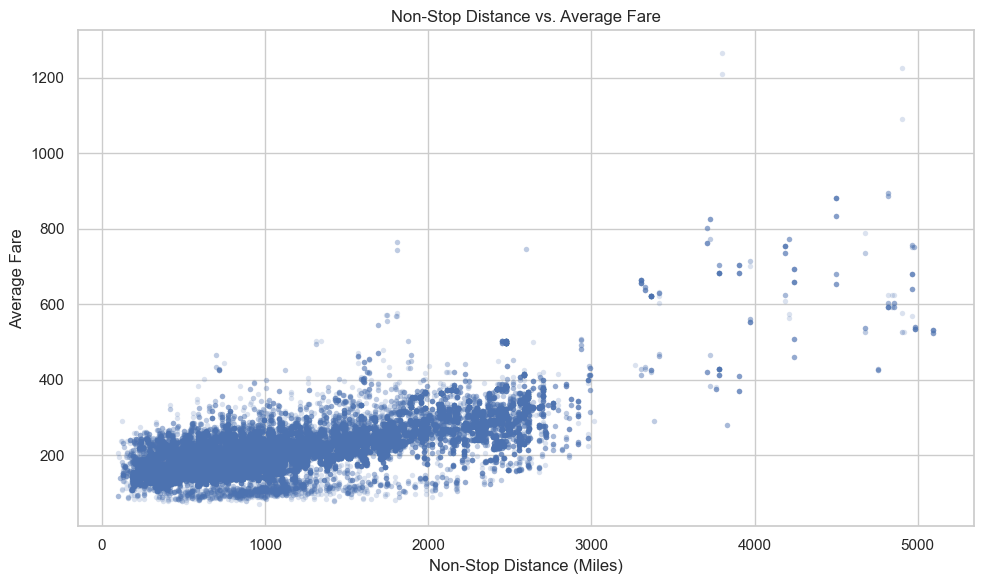

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="NonStopMiles",
    y=TARGET,
    alpha=0.2,
    s=15,
    linewidth=0,
    ax=ax,
)

ax.set_title("Non-Stop Distance vs. Average Fare")
ax.set_xlabel("Non-Stop Distance (Miles)")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

The scatter plot supports the correlation analysis: fares generally increase with route distance, although substantial variation remains at similar distances. This indicates that distance is important but insufficient on its own to explain fare differences.

### Market Concentration

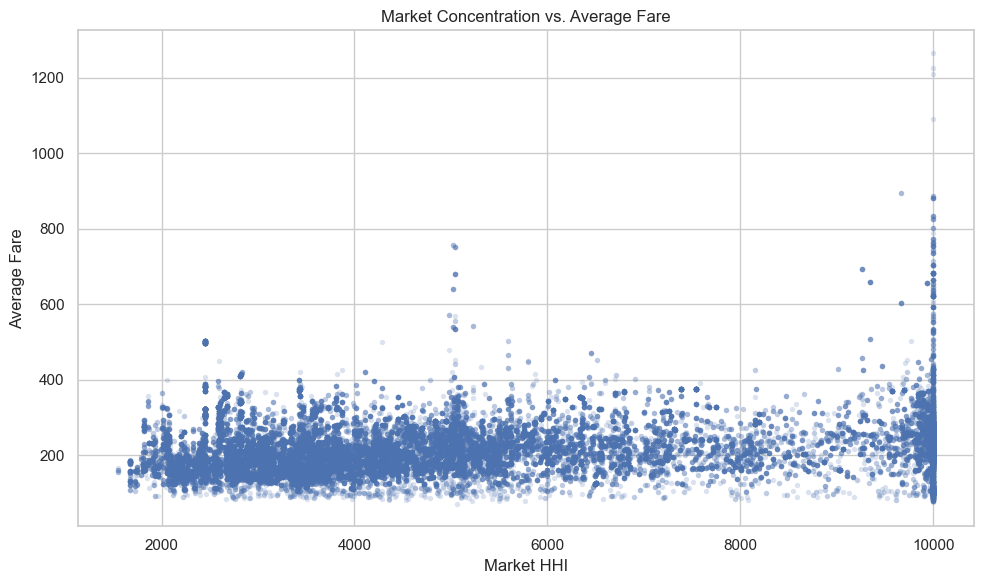

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=eda_sample,
    x="Market_HHI",
    y=TARGET,
    alpha=0.2,
    s=15,
    linewidth=0,
    ax=ax,
)

ax.set_title("Market Concentration vs. Average Fare")
ax.set_xlabel("Market HHI")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

### Binary Market and Route Characteristics

Several explanatory variables represent binary market or route conditions. Average and median fares are compared across their two categories before they are incorporated into predictive models.

In [19]:
binary_fare_summary = pd.concat(
    {
        feature: (
            df.groupby(feature)[TARGET]
            .agg(
                Observations="size",
                Mean_Fare="mean",
                Median_Fare="median",
            )
        )
        for feature in BINARY_FEATURES
    },
    names=["Feature", "Value"],
)

display(binary_fare_summary.round(2))

Observations  Mean_Fare  Median_Fare
Feature       Value                                       
RoundTrip     0.0000        307999   217.1800     204.3600
              1.0000       1273279   213.8300     201.7200
LCC_Comp      0.0000        171747   250.7600     222.1400
              1.0000       1409531   210.0600     198.8100
Multi_Airport 0.0000        476526   214.2200     206.1400
              1.0000       1104752   214.6000     199.7600
Slot          0.0000       1389408   214.3500     203.4800
              1.0000        191870   215.4200     189.3500
Non_Stop      0.0000        281373   248.2300     238.3700
              1.0000       1299905   207.1800     193.6500

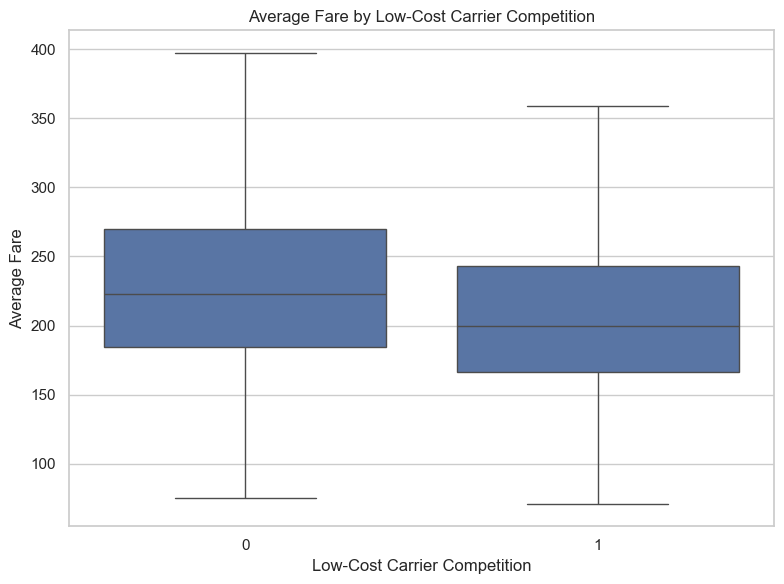

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=eda_sample,
    x="LCC_Comp",
    y=TARGET,
    showfliers=False,
    ax=ax,
)

ax.set_title("Average Fare by Low-Cost Carrier Competition")
ax.set_xlabel("Low-Cost Carrier Competition")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

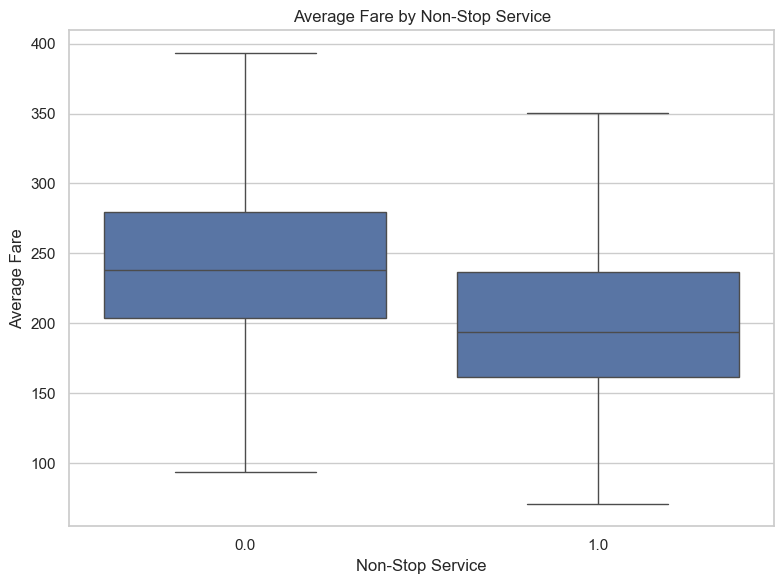

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=eda_sample,
    x="Non_Stop",
    y=TARGET,
    showfliers=False,
    ax=ax,
)

ax.set_title("Average Fare by Non-Stop Service")
ax.set_xlabel("Non-Stop Service")
ax.set_ylabel("Average Fare")

plt.tight_layout()
plt.show()

## Exploratory Analysis Summary

The exploratory analysis identifies several patterns relevant to the subsequent modeling stage:

- Average fares are strongly right-skewed and contain a substantial upper tail.
- Route distance has the strongest observed linear relationship with average fare, with both non-stop distance and market miles flown showing correlations of approximately 0.73.
- Market concentration and carrier market share show weaker but positive associations with average fares.
- Fare distributions also vary across market and service characteristics such as low-cost carrier competition and non-stop service.
- Several explanatory variables are related to one another, making regularized regression useful for evaluating linear relationships in the presence of correlated predictors.

These findings are descriptive and should not be interpreted as causal effects. The modeling stage therefore focuses on predictive performance and feature contribution rather than causal identification.

## 7. Modeling Strategy

The predictive analysis uses a reproducible sample of 200,000 observations. A common modeling sample and train-test split are used for all models so that their evaluation metrics are directly comparable.

Several columns in the dataset are encoded identifiers rather than continuous numerical variables. Treating values such as carrier, airport, or origin-destination IDs as ordinary numbers would impose artificial numerical relationships between categories.

The modeling strategy therefore:

- excludes raw city-market, airport, and origin-destination identifiers as numerical predictors;
- treats `Carrier` as a categorical feature;
- represents high-cardinality market, airport, and route identifiers using frequency encoding;
- fits frequency encodings using the training data only;
- uses the same training and test observations for every model;
- standardizes numerical features only for models that benefit from scaling.

The original frequency-encoded columns supplied with the dataset are recalculated from the training partition to avoid using information about the test-set distribution during preprocessing.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
CORE_NUMERIC_FEATURES = [
    "MktCoupons",
    "NonStopMiles",
    "RoundTrip",
    "Pax",
    "CarrierPax",
    "Market_share",
    "Market_HHI",
    "LCC_Comp",
    "Multi_Airport",
    "Circuity",
    "Slot",
    "Non_Stop",
    "MktMilesFlown",
]

FREQUENCY_ENCODING_MAP = {
    "OriginCityMarketID": "OriginCityMarketID_freq",
    "DestCityMarketID": "DestCityMarketID_freq",
    "OriginAirportID": "OriginAirportID_freq",
    "DestAirportID": "DestAirportID_freq",
    "ODPairID": "ODPairID_freq",
}

CATEGORICAL_FEATURES = [
    "Carrier",
]

FREQUENCY_FEATURES = list(FREQUENCY_ENCODING_MAP.values())

MODEL_NUMERIC_FEATURES = (
    CORE_NUMERIC_FEATURES
    + FREQUENCY_FEATURES
)

MODEL_FEATURES = (
    MODEL_NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

### Modeling Sample

The full dataset is retained for exploratory analysis. For model development, a fixed sample of 200,000 observations is used to keep ensemble-model training computationally practical while ensuring that every candidate model is evaluated on exactly the same observations.

In [24]:
modeling_sample = df.sample(
    n=min(MODELING_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE,
).copy()

train_df, test_df = train_test_split(
    modeling_sample,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Modeling sample: {len(modeling_sample):,} observations")
print(f"Training set:    {len(train_df):,} observations")
print(f"Test set:        {len(test_df):,} observations")

Modeling sample: 200,000 observations
Training set:    160,000 observations
Test set:        40,000 observations


### Frequency Encoding

High-cardinality identifiers are represented by their relative frequency in the training data.

For each identifier, the frequency mapping is estimated exclusively from the training partition and then applied to the test partition. An identifier that appears in the test data but not in the training data receives a frequency of zero.

The raw identifiers themselves are not supplied to the predictive models.

In [25]:
def apply_frequency_encoding(
    train_data,
    test_data,
    encoding_map,
):
    """Create train-fitted frequency-encoded features."""

    train_encoded = train_data.copy()
    test_encoded = test_data.copy()

    for source_column, encoded_column in encoding_map.items():
        frequency_map = (
            train_encoded[source_column]
            .value_counts(normalize=True)
        )

        train_encoded[encoded_column] = (
            train_encoded[source_column]
            .map(frequency_map)
        )

        test_encoded[encoded_column] = (
            test_encoded[source_column]
            .map(frequency_map)
            .fillna(0)
        )

    return train_encoded, test_encoded

In [26]:
train_df, test_df = apply_frequency_encoding(
    train_df,
    test_df,
    FREQUENCY_ENCODING_MAP,
)

In [27]:
X_train = train_df[MODEL_FEATURES].copy()
X_test = test_df[MODEL_FEATURES].copy()

y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

route_train = train_df["ODPairID"].copy()
route_test = test_df["ODPairID"].copy()

In [28]:
modeling_summary = pd.Series(
    {
        "Training observations": len(X_train),
        "Test observations": len(X_test),
        "Numerical features": len(MODEL_NUMERIC_FEATURES),
        "Categorical features": len(CATEGORICAL_FEATURES),
        "Missing values in X_train": int(X_train.isna().sum().sum()),
        "Missing values in X_test": int(X_test.isna().sum().sum()),
    },
    name="Value",
)

display(modeling_summary.to_frame())

,Value
Training observations,160000
Test observations,40000
Numerical features,18
Categorical features,1
Missing values in X_train,0
Missing values in X_test,0


In [29]:
assert X_train.index.intersection(X_test.index).empty
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

### Preprocessing Pipelines

Two preprocessing configurations are used while preserving the same underlying feature set.

For Linear, Ridge, and Lasso regression, numerical variables are standardized to zero mean and unit variance. This is particularly important for regularized regression because the penalty depends on coefficient magnitude.

For tree-based models, numerical variables are retained on their original scales because tree splitting is not sensitive to feature scaling.

In both cases, carrier codes are treated as categorical values and one-hot encoded rather than interpreted as numerical quantities.

In [30]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "carrier",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [31]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "carrier",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [32]:
feature_strategy = pd.DataFrame(
    {
        "Feature Group": [
            "Continuous / binary",
            "Frequency encoded",
            "Categorical",
            "Excluded raw identifiers",
        ],
        "Features": [
            ", ".join(CORE_NUMERIC_FEATURES),
            ", ".join(FREQUENCY_FEATURES),
            ", ".join(CATEGORICAL_FEATURES),
            ", ".join(
                [
                    "OriginCityMarketID",
                    "DestCityMarketID",
                    "OriginAirportID",
                    "DestAirportID",
                    "ODPairID",
                ]
            ),
        ],
    }
)

display(feature_strategy)

,Feature Group,Features
0,Continuous / binary,"MktCoupons, NonStopMiles, RoundTrip, Pax, Carr..."
1,Frequency encoded,"OriginCityMarketID_freq, DestCityMarketID_freq..."
2,Categorical,Carrier
3,Excluded raw identifiers,"OriginCityMarketID, DestCityMarketID, OriginAi..."
